In [49]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import shap
import torch
from matplotlib.ticker import MaxNLocator
from pandas import DataFrame
from torch.utils.data import DataLoader
from tqdm import tqdm

import thesis_utils as tuds
import thesis_utils as tum

# Data Preparation

In [50]:
# Model parameters
HORIZON = 1
BATCH_SIZE = 800
NUM_EPOCHS = 25
HIDDEN_SIZE = 128
N_LAYERS = 3
DROPOUT = 0.3
EMBEDDING_SIZE = 32

# Train parameters
TARGET = "EXPORT_centered"
FEATURES = [
  "contig", "comlang_off", "colony", "smctry",  # dist cepii categorical
]
N_SPLITS = 5
PATIENCE = 5
LEARNING_RATE = 0.01
WEIGHT_DECAY = 0.01
RANDOM_SEED = 16
KEEP_FRAC = 1.0
N_LAGS = 5
SUBSAMPLE_ENABLED = False
N_DYADS = 1000

SANCTION_COLS = ["arms", "military", "trade", "travel", "other"]

# Torch config
torch.manual_seed(RANDOM_SEED)
device = (
  torch.device("mps") if torch.backends.mps.is_available()
  else torch.device("cpu")
)

In [51]:
processed = pd.read_parquet(path="../../data/model/processed.parquet", engine="fastparquet")

df_nn: DataFrame = processed.copy(deep=True)
df_nn["dyad_id"] = df_nn["ISO3_reporter"] + "_" + df_nn["ISO3_partner"]
df_nn = df_nn.sort_values(by=["dyad_id", "Year"], ignore_index=True)

# Prepare sanction column as sum of all active boolean sanctions
df_nn["sanction"] = (df_nn[SANCTION_COLS]
                     .sum(axis=1)).astype(int)

# Coerce numerical columns to float
num_cols = ["distw", "GDP_reporter", "GDP_partner", "sanction", "contig",
            "comlang_off", "colony", "smctry", "Year", ]
df_nn[num_cols] = df_nn[num_cols].apply(pd.to_numeric, errors="coerce").astype(float)

# Drop NA in numerical columns
df_nn = df_nn.dropna(subset=num_cols)

# Cast "Year" to integer
df_nn["Year"] = df_nn["Year"].astype(int)

# Cast "dyad_id" to categorical
for col in ["dyad_id"]:
  df_nn[col] = pd.Categorical(df_nn[col], categories=sorted(df_nn[col].unique()))

# Define and center columns
center_columns = ["distw", "GDP_reporter", "GDP_partner", "EXPORT"]
for col in center_columns:
  median = df_nn[col].median()
  std_df = df_nn[col].std()
  df_nn[col + "_centered"] = (df_nn[col] - median) / std_df

# Add "distw_centered" to feature list
FEATURES += ["distw_centered"]

# Define columns to be lagged and lag them while appending the number of the lag to the column name
lag_cols = ["GDP_reporter_centered", "GDP_partner_centered", "sanction"]
for col in lag_cols:
  for index in range(1, N_LAGS + 1):
    df_nn[f"{col}_lag{index}"] = df_nn.groupby("dyad_id", observed=True)[col].shift(index)

# Drop NA again for the lags that produced NA
df_nn = df_nn.dropna()

# Add lagged column names to the feature list
FEATURES += [f"{c}_lag{index}" for c in lag_cols for index in range(1, N_LAGS + 1)]

In [52]:
df_nn

,ISO3_reporter,UNDS_reporter,CNAME_reporter,ISO3_partner,UNDS_partner,CNAME_partner,Year,GDP_reporter,GDP_partner,contig,...,GDP_partner_centered_lag1,GDP_partner_centered_lag2,GDP_partner_centered_lag3,GDP_partner_centered_lag4,GDP_partner_centered_lag5,sanction_lag1,sanction_lag2,sanction_lag3,sanction_lag4,sanction_lag5
5,AGO,024,Angola,ALB,008,Albania,1993,5.768720e+09,1.185315e+09,0.0,...,-0.012576,-0.012233,-0.011522,-0.011350,-0.011504,0.0,0.0,0.0,0.0,0.0
6,AGO,024,Angola,ALB,008,Albania,1994,4.438321e+09,1.880951e+09,0.0,...,-0.012167,-0.012576,-0.012233,-0.011522,-0.011350,0.0,0.0,0.0,0.0,0.0
7,AGO,024,Angola,ALB,008,Albania,1995,5.538749e+09,2.392765e+09,0.0,...,-0.011635,-0.012167,-0.012576,-0.012233,-0.011522,0.0,0.0,0.0,0.0,0.0
8,AGO,024,Angola,ALB,008,Albania,1996,7.526447e+09,3.199641e+09,0.0,...,-0.011243,-0.011635,-0.012167,-0.012576,-0.012233,0.0,0.0,0.0,0.0,0.0
9,AGO,024,Angola,ALB,008,Albania,1997,7.648377e+09,2.258514e+09,0.0,...,-0.010624,-0.011243,-0.011635,-0.012167,-0.012576,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1178542,ZWE,716,Zimbabwe,ZMB,894,Zambia,2018,3.415607e+10,2.631151e+10,1.0,...,0.006744,0.002979,0.003204,0.007715,0.008402,0.0,0.0,0.0,0.0,0.0
1178543,ZWE,716,Zimbabwe,ZMB,894,Zambia,2019,2.571741e+10,2.330867e+10,1.0,...,0.007080,0.006744,0.002979,0.003204,0.007715,0.0,0.0,0.0,0.0,0.0
1178544,ZWE,716,Zimbabwe,ZMB,894,Zambia,2020,2.686794e+10,1.813776e+10,1.0,...,0.004780,0.007080,0.006744,0.002979,0.003204,0.0,0.0,0.0,0.0,0.0
1178545,ZWE,716,Zimbabwe,ZMB,894,Zambia,2021,2.724052e+10,2.209642e+10,1.0,...,0.000819,0.004780,0.007080,0.006744,0.002979,0.0,0.0,0.0,0.0,0.0


# Load trained models and create dataloader

In [53]:
# 1) Load all models
checkpoints = {
  "GRU": torch.load("../../models/GRU-0_0003lr-0_05d-256hs-0wd-128bs-2layers-128es-kfolds8-hp.pt", map_location="cpu"),
  "GRU-new": torch.load("../../models/GRU-0_001lr-0_1d-128hs-0_001wd-64bs-2layers-64es-kfolds8-hp.pt",
                        map_location="cpu"),
  "LSTM": torch.load("../../models/LSTM-0_0003lr-0_05d-256hs-1e-06wd-128bs-3layers-128es-kfolds8-hp.pt",
                     map_location="cpu"),
  "LSTM-new": torch.load("../../models/LSTM-0_001lr-0_1d-256hs-1e-05wd-64bs-2layers-64es-kfolds6-hp.pt",
                         map_location="cpu"),
  # "XLSTM": torch.load("../../models/XLSTM-0_001lr-0_25d-128hs-0_0wd.pt", map_location="cpu"),
  "XLSTM-new": torch.load("../../models/XLSTM(sm)-0_0003lr-0_05d-256hs-0wd-128bs-2layers-128es-kfolds8-hp.pt",
                          map_location="cpu"),
}

# Save all models in a dictionary
models = { }
for name, ckpt in checkpoints.items():
  if name.startswith("GRU"):
    m = tum.DyadGRU(**ckpt["model_hyperparams"])
  elif name == "LSTM" or name == "LSTM-new":
    m = tum.DyadLSTM(**ckpt["model_hyperparams"])
  else:
    m = tum.DyadXLSTM(**ckpt["model_hyperparams"])
  m.load_state_dict(ckpt["model_state_dict"])
  m.to(device).eval()
  models[name] = m

# 2) Build the dataset & dataloader once
dataset, dyad_to_idx = tuds.make_panel_datasets_dyad_year(
  data=df_nn, features=FEATURES, target=TARGET, horizon=HORIZON
)

loader = DataLoader(
  dataset, batch_size=BATCH_SIZE, shuffle=False,
  num_workers=10, persistent_workers=True, prefetch_factor=2
)

# Additional check to see if the model is predicting the mean

In [54]:
# Check if the model is predicting the mean
all_preds = { name: [] for name in models }
all_truth = []
all_years = []

with torch.no_grad():
  for X, y, di, yr in tqdm(loader, desc="Predicting", unit="batch"):
    X, di = X.to(device), di.to(device)
    # collect truth & years once
    all_truth.append(y)
    all_years.append(yr)

    for name, m in models.items():
      y_hat = m(X, di).cpu()
      all_preds[name].append(y_hat)

Predicting: 100%|██████████| 1263/1263 [00:14<00:00, 87.98batch/s] 


In [55]:
years = torch.cat(all_years).numpy().flatten()
truth = torch.cat(all_truth).numpy().flatten()
for name in all_preds:
  all_preds[name] = torch.cat(all_preds[name]).numpy().flatten()

In [56]:
# 4) Invert centering back to exports
med = df_nn["EXPORT"].median()
sd = df_nn["EXPORT"].std()

truth = truth * sd + med
pred = { name: preds * sd + med for name, preds in all_preds.items() }

In [57]:
global_mean = truth.mean().item()

In [58]:
from sklearn.metrics import r2_score

mean_pred = np.full_like(truth, global_mean)

print(f"Baseline (mean model) R²: {r2_score(truth, mean_pred):.4f}")
for name, y_pred in pred.items():
  print(f"{name} R²: {r2_score(truth, y_pred):.4f}")

Baseline (mean model) R²: 0.0000
GRU R²: 0.9230
GRU-new R²: 0.9193
LSTM R²: 0.8198
LSTM-new R²: 0.9204
XLSTM-new R²: 0.9242


In [59]:
print(f"STD of true values: {np.std(truth):.4f}")
print(f"STD of mean predictions: {np.std(mean_pred):.4f}")
for name, y_pred in pred.items():
  print(f"STD of {name} predictions: {np.std(y_pred):.4f}")

STD of true values: 4875352.0000
STD of mean predictions: 0.0625
STD of GRU predictions: 4896174.0000
STD of GRU-new predictions: 4866283.5000
STD of LSTM predictions: 3484345.0000
STD of LSTM-new predictions: 4549097.5000
STD of XLSTM-new predictions: 4819205.0000


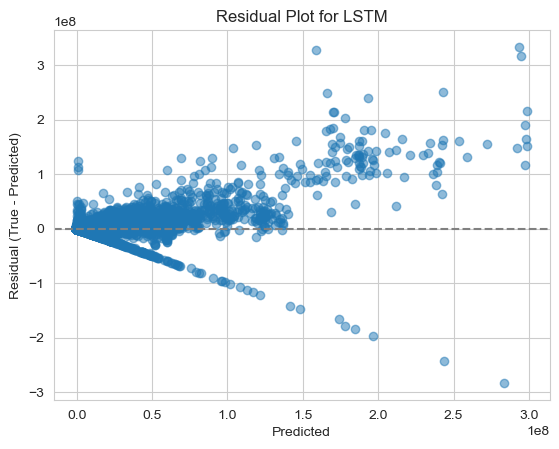

In [60]:
residuals = truth - pred["LSTM"]

plt.scatter(pred["LSTM"], residuals, alpha=0.5)
plt.axhline(0, color='gray', linestyle='--')
plt.xlabel("Predicted")
plt.ylabel("Residual (True - Predicted)")
plt.title("Residual Plot for LSTM")
plt.grid(True)
plt.show()

# TC-SHAP

In [61]:
# Extract dyads to be observed
FEATURE_LEN = len(FEATURES)

top_dyads = [
  "USA_CHN", "CHN_USA",
  "USA_CAN", "CAN_USA",
  "DEU_CHN", "CHN_DEU",
  "USA_DEU", "DEU_USA",
  "USA_MEX", "MEX_USA",
  "AUS_CHN", "CHN_AUS",
  "USA_JPN", "JPN_USA",
  "DEU_JPN", "JPN_DEU",
  "USA_AUS", "AUS_USA",
  "DEU_RUS", "RUS_DEU",
]

# Prepare model
model_tc_shap = models["XLSTM-new"]
model_tc_shap.eval()
model_tc_shap.to(device)

DyadXLSTM(
  (dyad_embed): Embedding(33672, 128)
  (xlstm): xLSTM(
    (layers): ModuleList(
      (0): sLSTMBlock(
        (layer_norm): LayerNorm((148,), eps=1e-05, elementwise_affine=True)
        (causal_conv): CausalConv1D(
          (conv): Conv1d(1, 1, kernel_size=(4,), stride=(1,), padding=(3,))
        )
        (Wz): BlockDiagonal(
          (blocks): ModuleList(
            (0): Linear(in_features=148, out_features=256, bias=True)
          )
        )
        (Wi): BlockDiagonal(
          (blocks): ModuleList(
            (0): Linear(in_features=148, out_features=256, bias=True)
          )
        )
        (Wf): BlockDiagonal(
          (blocks): ModuleList(
            (0): Linear(in_features=148, out_features=256, bias=True)
          )
        )
        (Wo): BlockDiagonal(
          (blocks): ModuleList(
            (0): Linear(in_features=148, out_features=256, bias=True)
          )
        )
        (Rz): BlockDiagonal(
          (blocks): ModuleList(
            

In [62]:
top_dyad_idxs = [dyad_to_idx[d] for d in top_dyads if d in dyad_to_idx]

In [63]:
# Collect samples for selected dyads
X_list, dyad_idx_list = [], []

for i in range(len(dataset)):
  X, y, dyad_idx, _ = dataset[i]
  if dyad_idx.item() in top_dyad_idxs:
    X_list.append(X)
    dyad_idx_list.append(dyad_idx)

In [64]:
X_filtered = torch.cat(X_list)  # (N, 1, D)
dyad_filtered = torch.stack(dyad_idx_list)  # (N,)
flat_X = X_filtered.reshape(len(X_filtered), -1).numpy()  # (N, D)
dyads_np = dyad_filtered.numpy().reshape(-1, 1)  # (N, 1)
X_plus_dyad = np.concatenate([flat_X, dyads_np], axis=1)  # (N, D + 1)

In [65]:
# Split for SHAP
X_back = X_plus_dyad[:50]  # background dataset for kernel explainer
X_explain = X_plus_dyad[50:]  # data to explain

In [66]:
def make_predict_fn(model, n_features, device):
  def predict_fn(flat_X_dyad: np.ndarray):
    X_flat = flat_X_dyad[:, :-1]  # shape: (N, D)
    dyads = flat_X_dyad[:, -1].astype(int)
    X = torch.tensor(X_flat, dtype=torch.float32).reshape(-1, 1, n_features).to(device)
    dyads = torch.tensor(dyads, dtype=torch.long).to(device)
    with torch.no_grad():
      preds = model(X, dyads).cpu().numpy()
    return preds.reshape(-1)

  return predict_fn

In [67]:
# Run SHAP
predict_fn = make_predict_fn(model_tc_shap, n_features=len(FEATURES), device=device)
explainer = shap.KernelExplainer(predict_fn, X_back)
shap_values = explainer.shap_values(X_explain)

# Convert and aggregate
shap_vals = np.array(shap_values)  # shape: (N, D + 1)
shap_vals_features_only = shap_vals[:, :-1]
avg_shap = np.mean(shap_vals_features_only, axis=0)  # shape: (D,)

  0%|          | 0/550 [00:00<?, ?it/s]

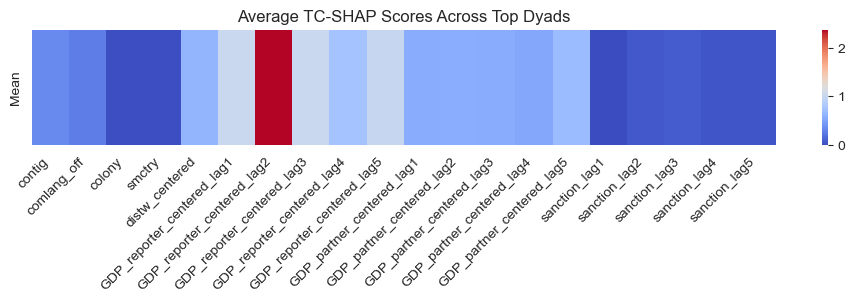

In [68]:
# Plot heatmap
plt.figure(figsize=(12, 1.5))
sns.heatmap(avg_shap.reshape(1, -1), cmap="coolwarm", xticklabels=FEATURES, yticklabels=["Mean"])
plt.title("Average TC-SHAP Scores Across Top Dyads")
plt.xticks(rotation=45, ha="right")
plt.show()

In [69]:
reciprocal_pairs = [
  ("USA_CHN", "CHN_USA"),
  ("USA_CAN", "CAN_USA"),
  ("DEU_CHN", "CHN_DEU"),
  ("USA_DEU", "DEU_USA"),
  ("USA_MEX", "MEX_USA"),
  ("AUS_CHN", "CHN_AUS"),
  ("USA_JPN", "JPN_USA"),
  ("DEU_JPN", "JPN_DEU"),
  ("USA_AUS", "AUS_USA"),
  ("DEU_RUS", "RUS_DEU"),
]

avg_tc_shap_per_dyad = { }

for pair in reciprocal_pairs:
  print(pair)

  dyad_pair_idx = [dyad_to_idx[d] for d in pair if d in dyad_to_idx]
  X_list, dyad_idx_list = [], []

  for i in range(len(dataset)):
    X, y, dyad_idx, _ = dataset[i]
    if dyad_idx.item() in dyad_pair_idx:
      X_list.append(X)
      dyad_idx_list.append(dyad_idx)

  if not X_list:
    continue

  X_filtered = torch.cat(X_list)  # (N, 1, D)
  dyad_filtered = torch.stack(dyad_idx_list)  # (N,)
  flat_X = X_filtered.reshape(len(X_filtered), -1).numpy()
  dyads_np = dyad_filtered.numpy().reshape(-1, 1)
  X_plus_dyad = np.concatenate([flat_X, dyads_np], axis=1)

  # background and explain set
  X_back = X_plus_dyad[:50]
  X_explain = X_plus_dyad[50:]

  predict_fn = make_predict_fn(model_tc_shap, n_features=len(FEATURES), device=device)
  explainer = shap.KernelExplainer(predict_fn, X_back)
  shap_values = explainer.shap_values(X_explain)

  shap_vals = np.array(shap_values)
  shap_vals_features_only = shap_vals[:, :-1]
  avg_shap = np.mean(shap_vals_features_only, axis=0)

  avg_tc_shap_per_dyad[pair] = avg_shap

('USA_CHN', 'CHN_USA')


  0%|          | 0/10 [00:00<?, ?it/s]

('USA_CAN', 'CAN_USA')


  0%|          | 0/10 [00:00<?, ?it/s]

('DEU_CHN', 'CHN_DEU')


...

  0%|          | 0/10 [00:00<?, ?it/s]

('USA_AUS', 'AUS_USA')


  0%|          | 0/10 [00:00<?, ?it/s]

('DEU_RUS', 'RUS_DEU')


  0%|          | 0/10 [00:00<?, ?it/s]

In [70]:
avg_tc_shap_per_dyad

{('USA_CHN',
  'CHN_USA'): array([ 0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
         0.63239361,  4.82502069,  2.10917407,  1.05565829,  1.86868811,
         0.3511494 ,  0.30882822,  0.07125767,  0.        ,  0.        ,
        -5.08817801, -0.90985229, -0.85339388, -0.5980302 , -1.46972718]),
 ('USA_CAN',
  'CAN_USA'): array([ 0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
         1.10461267,  6.16339764,  1.76217689, -0.09584489,  0.98996043,
        -0.07248685, -3.8796792 , -0.14914221,  0.        , -0.23972273,
         0.6760376 ,  0.64626797,  0.11492759,  0.46334046,  0.44777551]),
 ('DEU_CHN',
  'CHN_DEU'): array([0.        , 0.        , 0.        , 0.        , 0.        ,
        0.85233033, 0.40504691, 1.01463299, 0.70657814, 1.05553585,
        1.20209368, 4.40068065, 1.43266238, 0.44396853, 1.03391096,
        0.        , 0.53581198, 0.30312109, 0.        , 0.08416628]),
 ('USA_DEU',
  'DEU_USA'): array([ 0.        ,  0.        , 

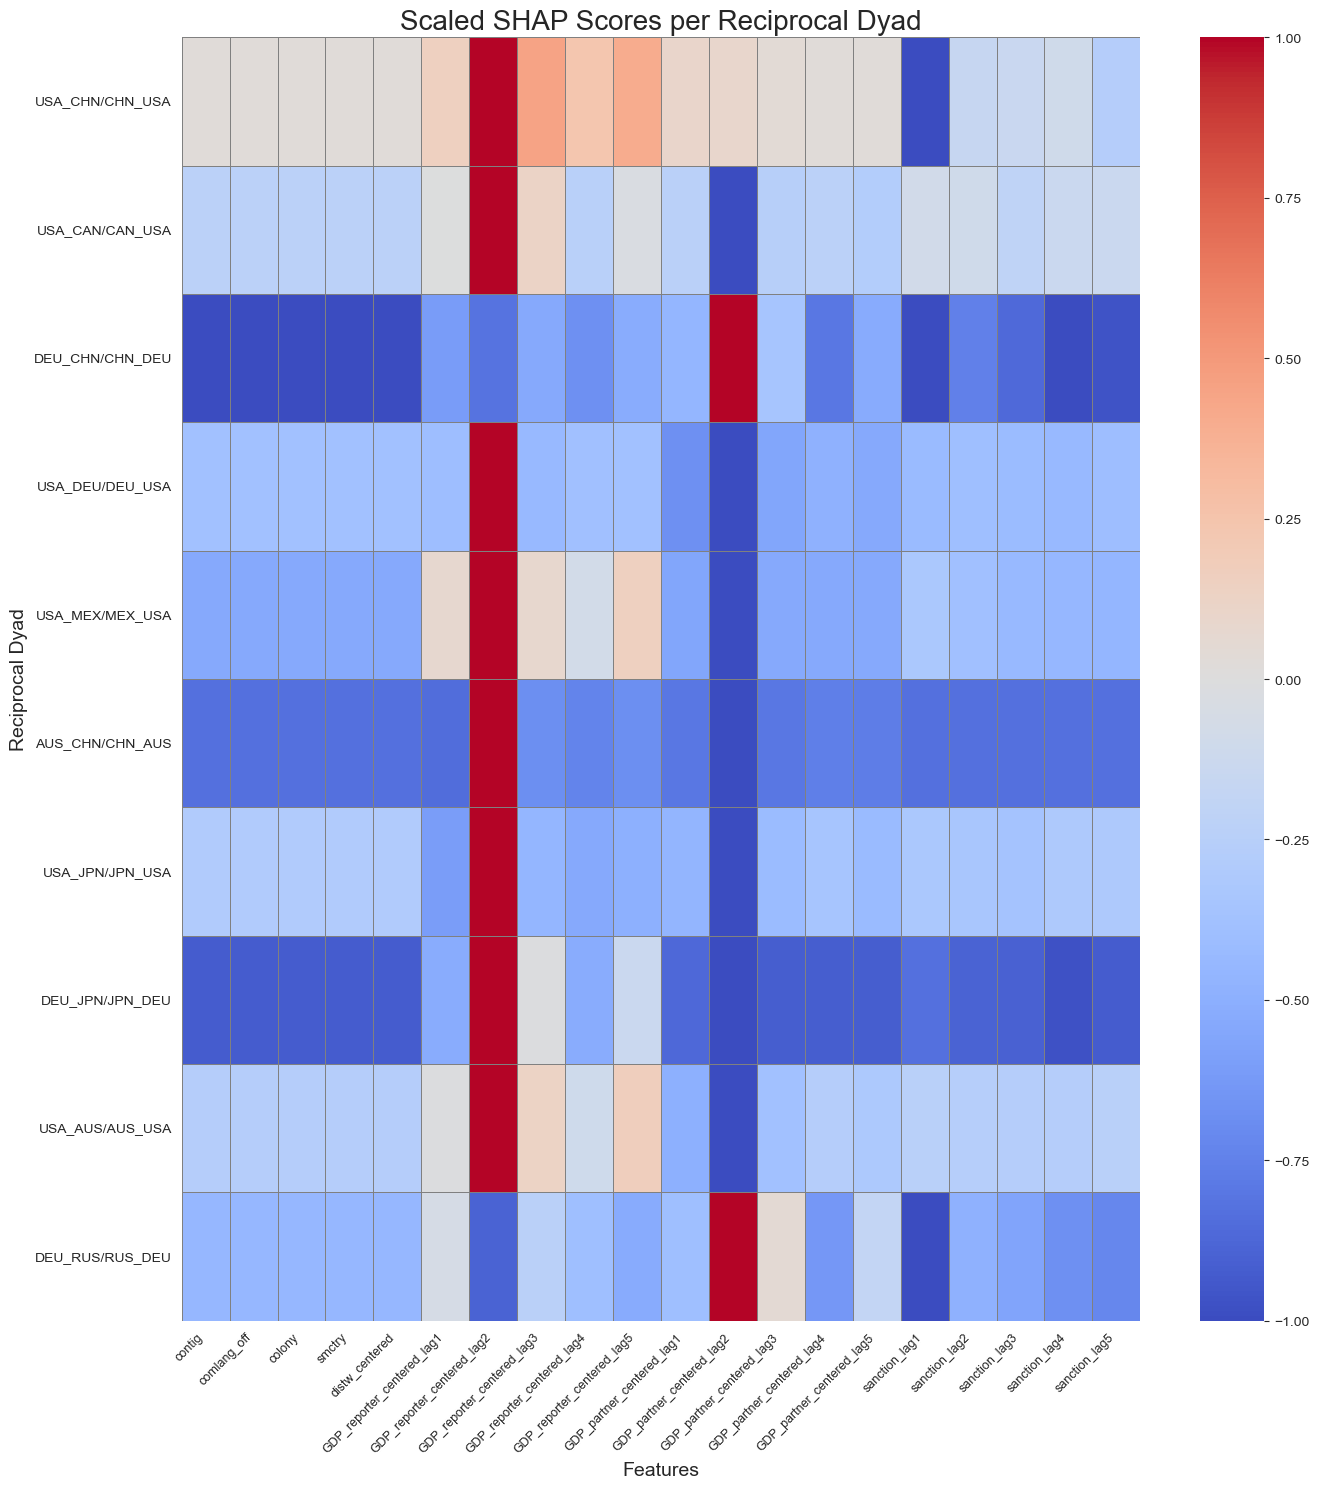

In [71]:
dyad_labels = []
heatmap_rows = []

for (dyad1, dyad2), shap_vals in avg_tc_shap_per_dyad.items():
  avg_vals = shap_vals

  min_val = np.min(avg_vals)
  max_val = np.max(avg_vals)

  if max_val - min_val < 1e-8:
    scaled_vals = np.zeros_like(avg_vals)
  else:
    scaled_vals = 2 * (avg_vals - min_val) / (max_val - min_val) - 1

  heatmap_rows.append(scaled_vals)
  dyad_labels.append(f"{dyad1}/{dyad2}")

# Stack into 2D matrix
heatmap_matrix = np.stack(heatmap_rows, axis=0)

# Plot single 2D heatmap
plt.figure(figsize=(14, 1.5 * len(dyad_labels)))
sns.heatmap(
  heatmap_matrix,
  cmap="coolwarm",
  xticklabels=FEATURES,
  yticklabels=dyad_labels,
  cbar=True,
  linewidths=0.5,
  linecolor="gray"
)
plt.xticks(rotation=45, ha="right", fontsize=9)
plt.title("Scaled SHAP Scores per Reciprocal Dyad", fontsize=20)
plt.xlabel("Features", fontsize=14)
plt.ylabel("Reciprocal Dyad", fontsize=14)
plt.tight_layout()
plt.show()

# Partial dependence of sanctions

## PDP for sanction lags

In [72]:
DYAD_NAME = "USA_CHN"
GDP_QUANTILE = 0.75

# Check if all geo features remain the same across the rows (sanity check)
geo_features = [
  "contig",
  "comlang_off",
  "comlang_ethno",
  "colony",
  "smctry",
  "distcap",
  "distw_centered"
]

dyad_df = df_nn[df_nn["dyad_id"] == DYAD_NAME]

for feat in geo_features:
  if not (dyad_df[feat].nunique() == 1):
    print(f"Feature '{feat}' is NOT constant — unique values: {dyad_df[feat].unique()}")

In [73]:
GDP_FEATURE_LAGS = [
                     f"GDP_reporter_centered_lag{i}" for i in range(1, 6)
                   ] + [
                     f"GDP_partner_centered_lag{i}" for i in range(1, 6)
                   ]

In [74]:
SANCTION_FEATURE_LAGS = [f"sanction_lag{i}" for i in range(1, 6)]

In [75]:
feature_to_index = { feat: i for i, feat in enumerate(FEATURES) }

In [76]:
dyad_idx_value = dyad_to_idx[DYAD_NAME]
gdp_quantiles = dyad_df[GDP_FEATURE_LAGS].quantile(GDP_QUANTILE)

for i in range(len(dataset)):
  X, y, dyad_idx, _ = dataset[i]
  if dyad_idx.item() == dyad_idx_value:
    X_fixed = X.clone()
    break

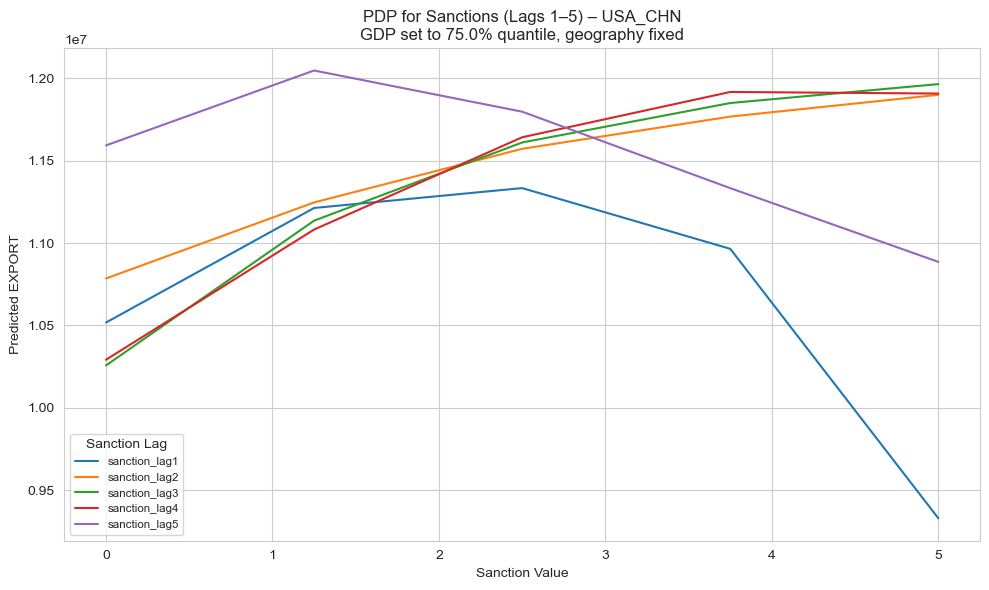

In [82]:
model = models["XLSTM-new"]
model.eval()
model.to(device)

pdp_records = []

median_export = df_nn["EXPORT"].median()
std_export = df_nn["EXPORT"].std()

for lag_feat in SANCTION_FEATURE_LAGS:
  feat_idx = feature_to_index[lag_feat]
  min_val, max_val = 0, 5
  lag_values = torch.linspace(min_val, max_val, 5).to(device)

  X_varied = X_fixed.repeat(len(lag_values), 1)
  X_varied[:, feat_idx] = lag_values

  X_seq = X_varied.unsqueeze(1).to(device)
  dyads = torch.full((len(lag_values),), dyad_idx_value, dtype=torch.long).to(device)

  with torch.no_grad():
    preds = model(X_seq, dyads).squeeze().cpu().numpy()

  preds = preds * std_export + median_export

  pdp_records.extend([
    { "sanction_lag": lag_feat, "value": v.item(), "prediction": p }
    for v, p in zip(lag_values.cpu(), preds)
  ])

pdp_df = pd.DataFrame(pdp_records)

plt.figure(figsize=(10, 6))
sns.lineplot(data=pdp_df, x="value", y="prediction", hue="sanction_lag", palette="tab10")
plt.xlabel("Sanction Value")
plt.ylabel("Predicted EXPORT")
plt.title(f"PDP for Sanctions (Lags 1–5) – {DYAD_NAME}\nGDP set to {GDP_QUANTILE * 100}% quantile, geography fixed")
plt.grid(True)
plt.legend(title="Sanction Lag", fontsize="small")
plt.tight_layout()
plt.show()

## 2D PDP

In [78]:
def pdp_2d_gdp_reporter_vs_sanction(
    dyad_id: str,
    model_name: str = "GRU",
    gdp_reporter_lag: int = 2,  # K in GDP_reporter_centered_lagK
    sanction_lag: int = 1,  # J in sanction_lagJ
    sanc_min: float = 0.0,
    sanc_max: float = 5.0,
    n_gdp: int = 60,  # grid resolution along GDP
    n_sanc: int = 31,  # grid resolution along sanction
    batch_size: int = 2048,  # for fast batched inference
    uncenter_export: bool = False  # if True, convert predictions back to raw EXPORT units
):
  model = models[model_name].eval().to(device)

  # --- columns we’ll need ---
  gdp_rep = [f"GDP_reporter_centered_lag{i}" for i in range(1, 6)]
  gdp_par = [f"GDP_partner_centered_lag{i}" for i in range(1, 6)]
  sanc_cols = [f"sanction_lag{i}" for i in range(1, 6)]
  geo_cols = ["contig", "comlang_off", "colony", "smctry", "distw_centered"]
  feat_idx = { f: i for i, f in enumerate(FEATURES) }

  # --- dyad slice ---
  df_nn["dyad_id"] = df_nn["ISO3_reporter"] + "_" + df_nn["ISO3_partner"]
  dyad_df = df_nn[df_nn["dyad_id"] == dyad_id].copy()
  assert len(dyad_df), f"No rows for dyad {dyad_id}"
  dyad_idx_val = dyad_to_idx[dyad_id]

  # --- find one base sample from your dataset wrapper ---
  X_base = None
  for i in range(len(dataset)):
    X_i, _, dy_i, _ = dataset[i]
    if dy_i.item() == dyad_idx_val:
      X_base = X_i.clone()  # (1, D)
      break
  assert X_base is not None, f"No sample found for dyad {dyad_id}"

  # --- sanity: warn if geo is not constant ---
  for c in geo_cols:
    if dyad_df[c].nunique() != 1:
      print(f"[warn] {c} is not constant for {dyad_id}: {dyad_df[c].unique()}")

  # --- fix geography to a constant of this dyad ---
  for c in geo_cols:
    X_base[0, feat_idx[c]] = float(dyad_df[c].iloc[0])

  # --- fix ALL GDP lags to dyad Q75 (reporter & partner), we’ll vary only one reporter lag below ---
  q75 = dyad_df[gdp_rep + gdp_par].quantile(0.75)
  for c in (gdp_rep + gdp_par):
    X_base[0, feat_idx[c]] = float(q75[c])

  # --- fix ALL sanctions to 0 (we’ll vary only the chosen one below) ---
  for c in sanc_cols:
    X_base[0, feat_idx[c]] = 0.0

  # --- build grids (centered values) ---
  gdp_col = f"GDP_reporter_centered_lag{gdp_reporter_lag}"
  sanc_col = f"sanction_lag{sanction_lag}"

  # GDP grid from dyad-specific min->max of the chosen lag (centered units)
  gdp_min = float(dyad_df[gdp_col].min())
  gdp_max = float(dyad_df[gdp_col].max())
  if not np.isfinite(gdp_min) or not np.isfinite(gdp_max) or abs(gdp_max - gdp_min) < 1e-9:
    # fall back to a small span if degenerate
    gdp_min, gdp_max = -0.5, 0.5
  gdp_grid = np.linspace(gdp_min, gdp_max, n_gdp)
  sanc_grid = np.linspace(sanc_min, sanc_max, n_sanc)

  # mesh
  G, S = np.meshgrid(gdp_grid, sanc_grid)  # shapes (n_sanc, n_gdp)

  # --- build a big batch of inputs for all grid points ---
  N = n_gdp * n_sanc
  X_batch = X_base.repeat(N, 1)  # (N, D)
  X_batch[:, feat_idx[gdp_col]] = torch.tensor(G.ravel(), dtype=torch.float32)
  X_batch[:, feat_idx[sanc_col]] = torch.tensor(S.ravel(), dtype=torch.float32)

  # Still keep *other* sanctions at 0 (already set). GDP partner & other reporter lags at Q75 (already set).

  # --- run model in batches ---
  preds = np.empty(N, dtype=np.float32)
  dyads_tensor = torch.full((N,), dyad_idx_val, dtype=torch.long, device=device)

  with torch.no_grad():
    for start in range(0, N, batch_size):
      end = min(start + batch_size, N)
      xb = X_batch[start:end].unsqueeze(1).to(device)  # (B, 1, D)
      dyb = dyads_tensor[start:end]
      preds[start:end] = model(xb, dyb).squeeze(-1).detach().cpu().numpy()

  # optional: convert EXPORT back to raw units
  if uncenter_export:
    export_median = df_nn["EXPORT"].median()
    export_std = df_nn["EXPORT"].std()
    preds = preds * export_std + export_median

  Z = preds.reshape(n_sanc, n_gdp)  # rows: sanction, cols: GDP

  # --- plot: heatmap & contourf side-by-side ---
  fig, axes = plt.subplots(1, 2, figsize=(14, 5))

  # Heatmap
  im1 = axes[0].imshow(
    Z, aspect="auto", origin="lower", cmap="viridis",
    extent=[gdp_grid.min(), gdp_grid.max(), sanc_grid.min(), sanc_grid.max()]
  )
  axes[0].set_title(f"Heatmap — {dyad_id} | {model_name}", pad=15)
  axes[0].set_xlabel(f"{gdp_col} (centered)")
  axes[0].set_ylabel(sanc_col)
  axes[0].xaxis.set_major_locator(MaxNLocator(nbins=6))
  axes[0].yaxis.set_major_locator(MaxNLocator(nbins=6))
  fig.colorbar(im1, ax=axes[0])

  cf = axes[1].contourf(gdp_grid, sanc_grid, Z, levels=20, cmap="viridis")
  axes[1].set_title(f"Contourf — {dyad_id} | {model_name}", pad=15)
  axes[1].set_xlabel(f"{gdp_col} (centered)")
  axes[1].set_ylabel(sanc_col)
  axes[1].xaxis.set_major_locator(MaxNLocator(nbins=6))
  axes[1].yaxis.set_major_locator(MaxNLocator(nbins=6))
  fig.colorbar(cf, ax=axes[1])

  plt.tight_layout()
  plt.show()


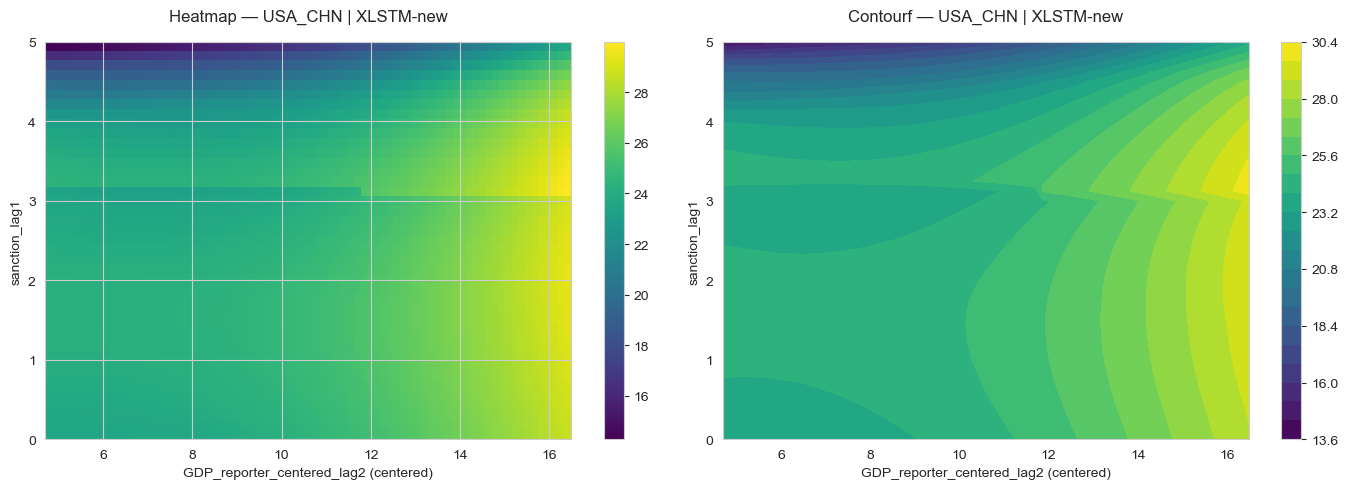

In [83]:
pdp_2d_gdp_reporter_vs_sanction(
  dyad_id="USA_CHN",
  model_name="XLSTM-new",
  gdp_reporter_lag=2,
  sanction_lag=1,
  sanc_min=0.0,
  sanc_max=5.0,
  n_gdp=80,
  n_sanc=41,
  batch_size=2048,
  uncenter_export=False,
)

## 3D PDP

In [80]:
def pdp_3d_surface(
    dyad_id: str,
    model_name: str = "GRU",
    gdp_reporter_lag: int = 2,
    sanction_lag: int = 1,
    sanc_min: float = 0.0,
    sanc_max: float = 5.0,
    n_gdp: int = 60,
    n_sanc: int = 31,
    batch_size: int = 2048,
    uncenter_export: bool = False
):
  # --- get model ---
  model = models[model_name].eval().to(device)

  gdp_rep = [f"GDP_reporter_centered_lag{i}" for i in range(1, 6)]
  gdp_par = [f"GDP_partner_centered_lag{i}" for i in range(1, 6)]
  sanc_cols = [f"sanction_lag{i}" for i in range(1, 6)]
  geo_cols = ["contig", "comlang_off", "colony", "smctry", "distw_centered"]
  feat_idx = { f: i for i, f in enumerate(FEATURES) }

  df_nn["dyad_id"] = df_nn["ISO3_reporter"] + "_" + df_nn["ISO3_partner"]
  dyad_df = df_nn[df_nn["dyad_id"] == dyad_id].copy()
  dyad_idx_val = dyad_to_idx[dyad_id]

  X_base = None
  for i in range(len(dataset)):
    X_i, _, dy_i, _ = dataset[i]
    if dy_i.item() == dyad_idx_val:
      X_base = X_i.clone()
      break

  for c in geo_cols:
    X_base[0, feat_idx[c]] = float(dyad_df[c].iloc[0])

  q75 = dyad_df[gdp_rep + gdp_par].quantile(0.75)
  for c in (gdp_rep + gdp_par):
    X_base[0, feat_idx[c]] = float(q75[c])

  for c in sanc_cols:
    X_base[0, feat_idx[c]] = 0.0

  gdp_col = f"GDP_reporter_centered_lag{gdp_reporter_lag}"
  sanc_col = f"sanction_lag{sanction_lag}"

  gdp_min = float(dyad_df[gdp_col].min())
  gdp_max = float(dyad_df[gdp_col].max())
  gdp_grid = np.linspace(gdp_min, gdp_max, n_gdp)
  sanc_grid = np.linspace(sanc_min, sanc_max, n_sanc)

  G, S = np.meshgrid(gdp_grid, sanc_grid)

  N = n_gdp * n_sanc
  X_batch = X_base.repeat(N, 1)
  X_batch[:, feat_idx[gdp_col]] = torch.tensor(G.ravel(), dtype=torch.float32)
  X_batch[:, feat_idx[sanc_col]] = torch.tensor(S.ravel(), dtype=torch.float32)

  preds = np.empty(N, dtype=np.float32)
  dyads_tensor = torch.full((N,), dyad_idx_val, dtype=torch.long, device=device)

  with torch.no_grad():
    for start in range(0, N, batch_size):
      end = min(start + batch_size, N)
      xb = X_batch[start:end].unsqueeze(1).to(device)
      dyb = dyads_tensor[start:end]
      preds[start:end] = model(xb, dyb).squeeze(-1).cpu().numpy()

  if uncenter_export:
    export_median = df_nn["EXPORT"].median()
    export_std = df_nn["EXPORT"].std()
    preds = preds * export_std + export_median

  Z = preds.reshape(n_sanc, n_gdp)

  # --- 3D Surface Plot ---
  fig = plt.figure(figsize=(10, 6))
  ax = fig.add_subplot(111, projection="3d")
  surf = ax.plot_surface(G, S, Z, cmap="viridis", edgecolor="none")
  ax.set_xlabel(f"{gdp_col} (centered)")
  ax.set_ylabel(f"{sanc_col}")
  ax.set_zlabel("Predicted EXPORT" + ("" if not uncenter_export else " (raw)"))
  ax.set_title(f"3D PDP — {dyad_id} | {model_name}", pad=20)
  ax.view_init(elev=20, azim=50)
  fig.colorbar(surf, ax=ax, shrink=0.5, aspect=8)
  plt.show()

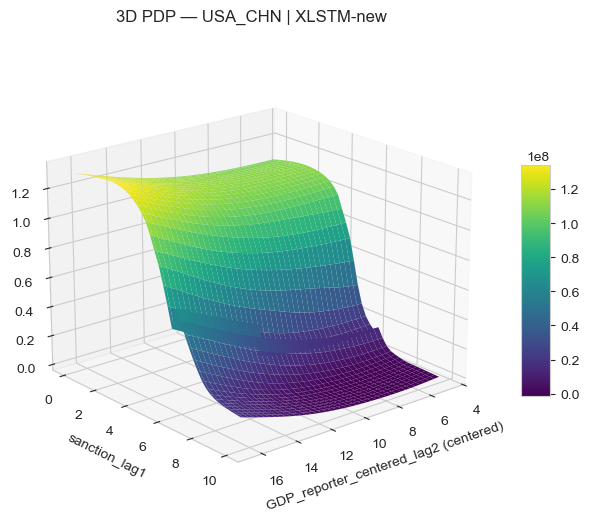

In [86]:
pdp_3d_surface(
  dyad_id="USA_CHN",
  model_name="XLSTM-new",
  gdp_reporter_lag=2,
  sanction_lag=1,
  sanc_min=0.0,
  sanc_max=10.0,
  n_gdp=80,
  n_sanc=41,
  batch_size=2048,
  uncenter_export=True,
)